# Training CFP with a morphological target on screws images

This notebook is inspired by `Example_screws_filtering.ipynb`, but changes the target so that `preserve_root=True` is compatible with the learning problem.

Instead of training the CFP layer directly against a binary mask, we train it against a gray-level morphological target:

- where the mask is foreground, the target is the input gray level;
- where the mask is background, the target is the root level of the max-tree, i.e. the global minimum after the `uint8` tree conversion.

This asks the layer to flatten the background to the baseline while preserving the marked structures. That is a connected-filtering task, not a direct segmentation task.

In [27]:
# If running outside a local checkout and mtlearn is not installed, uncomment:
# %pip install mtlearn

from pathlib import Path
import random
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import torch

# Prefer the local checkout when the notebook is launched from this repository.
# In Colab or another clean environment, uncomment the pip install above instead.
repo_root = Path.cwd()
for candidate in (repo_root, *repo_root.parents):
    if (candidate / "mtlearn" / "python" / "mtlearn").is_dir():
        local_python = candidate / "mtlearn" / "python"
        if str(local_python) not in sys.path:
            sys.path.insert(0, str(local_python))
        break

import mtlearn
from mtlearn import morphology

SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
BATCH_SIZE = 8
# Keep the default short enough for an example. Increase to 100 for a smoother curve.
NUM_EPOCHS = 100
LEARNING_RATE = 0.08
FOREGROUND_WEIGHT_CAP = 50.0
PLOT_SAMPLES = 3

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
generator = torch.Generator(device="cpu")
generator.manual_seed(SEED)

print("mtlearn:", mtlearn.__file__)
print("device:", DEVICE)

mtlearn: /Volumes/SSD/GitHub/mtlearn/mtlearn/python/mtlearn/__init__.py
device: mps


## Load data

The input loading flags follow the original screws notebook. Inputs and masks are loaded in `[0, 1]`, but the CFP reconstruction comes from `uint8` tree altitudes. For losses and displays, CFP outputs are divided by `255`.

In [28]:
num_cols, num_rows = (int(1177 * 0.5), int(1324 * 0.499))
dir_name = str(mtlearn.data.ensure_dataset("screws_segmentation"))

dataset = mtlearn.datasets.PairedImageDataset(
    root_dir=dir_name,
    grayscale_in=True,
    invert_in=True,
    invert_target=True,
    numRows=num_rows,
    numCols=num_cols,
    scale_in=True,
    suffix_in="_in",
    suffix_target="_target",
)

trainset, testset = dataset.train_test_split(test_size=0.3, random_state=SEED)
# Keep dataset tensors on CPU. The precomputed loaders move only mini-batches to DEVICE.
trainset = list(trainset)
testset = list(testset)

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=False,
    generator=generator,
)
testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=False,
)

num_pos = sum(int((y > 0.5).sum()) for _, y, _ in trainset)
num_pixels = sum(int(y.numel()) for _, y, _ in trainset)
num_neg = num_pixels - num_pos

print("resolution:", num_cols, "x", num_rows)
print("train/test:", len(trainset), len(testset))
print("foreground fraction:", num_pos / num_pixels)
print("suggested foreground weight:", num_neg / max(num_pos, 1))

screws_segmentation: already available at /Volumes/SSD/GitHub/mtlearn/dat/screws_segmentation
resolution: 588 x 660
train/test: 34 15
foreground fraction: 0.01975797894915542
suggested foreground weight: 49.612464087211016


## Morphological target

For a max-tree, the root level is the global minimum of the image used to build the tree. Because the layer converts normalized inputs to `uint8` before tree construction, the target uses the same quantized scale.

The target is:

```text
target(x, mask) = x_uint8 / 255       if mask = 1
                  min(x_uint8) / 255  if mask = 0
```

A weighted MSE is used because foreground pixels are rare in this dataset. The foreground weight is computed per image so the cached target does not depend on future DataLoader shuffling.

In [29]:
def input_as_tree_unit(x):
    """Match the quantized image scale used internally to build CFP trees."""
    x_u8 = (torch.clamp(x.detach(), 0.0, 1.0) * 255.0).to(torch.uint8)
    return x_u8.float().to(x.device) / 255.0


def morphological_target(x, mask):
    """Build the gray-level target once, outside the training loop.

    For max-tree filtering, the root is the quantized global minimum. The
    target keeps foreground gray levels and flattens background to that root.
    Foreground weights are computed per image so they do not depend on batch
    order after the target has been cached.
    """
    x_tree = input_as_tree_unit(x)
    root = x_tree.flatten(2).amin(dim=2).view(x.shape[0], x.shape[1], 1, 1)
    foreground = mask > 0.5
    target = torch.where(foreground, x_tree, root)

    foreground_flat = foreground.flatten(1).float()
    fg_count = foreground_flat.sum(dim=1).view(-1, 1, 1, 1).clamp_min(1.0)
    bg_count = foreground_flat.shape[1] - fg_count
    fg_weight = torch.clamp(
        bg_count / fg_count,
        max=torch.tensor(FOREGROUND_WEIGHT_CAP, device=x.device),
    )
    weights = torch.where(foreground, fg_weight, torch.ones_like(target))
    return target, weights, root, foreground


def cfp_unit_output(layer, model_input):
    return layer(model_input) / 255.0


x0, y0, name0 = trainset[0]
target0, weights0, root0, mask0 = morphological_target(x0.unsqueeze(0), y0.unsqueeze(0))
print("sample:", name0)
print("input min/max:", float(x0.min()), float(x0.max()))
print("root level:", float(root0.squeeze()))
print("target min/max:", float(target0.min()), float(target0.max()))
print("foreground weight:", float(weights0[mask0].mean()))

sample: 07_in.jpg
input min/max: 0.16470588743686676 0.9803921580314636
root level: 0.16470588743686676
target min/max: 0.16470588743686676 0.9803921580314636
foreground weight: 49.458980560302734


## Two matched CFP filters

The layer has two output specs. They share tree type, attributes, normalization, optimizer, and target. The only spec-level difference is `preserve_root`.

In [30]:
Type = morphology.AttributeType
attributes = (
    Type.AREA,
    Type.LENGTH_MAJOR_AXIS,
    Type.LENGTH_MINOR_AXIS,
    Type.INERTIA,
    Type.CIRCULARITY,
    Type.GRAY_HEIGHT,
    Type.RECTANGULARITY,
)

cfp_layer = mtlearn.layers.ConnectedFilterPreprocessingLayer(
    in_channels=1,
    filter_specs=[
        {
            "name": "root_filtered",
            "tree_type": morphology.TreeType.MAX_TREE,
            "attributes": attributes,
            "preserve_root": False,
        },
        {
            "name": "root_preserved",
            "tree_type": morphology.TreeType.MAX_TREE,
            "attributes": attributes,
            "preserve_root": True,
        },
    ],
    device=DEVICE,
    clamp=None,
)

t0 = time.time()
# First cache: tree topology, attributes, and normalization statistics.
# This is the expensive morphology part that the CFP layer already supports.
trainloader_cached = cfp_layer.build_dataloader_cached(trainloader)
testloader_cached = cfp_layer.build_dataloader_cached_fixed_stats(
    testloader,
    index_offset=len(trainset),
)
cfp_layer.init_identity_with_bias()
print("tree cache time seconds:", round(time.time() - t0, 3))
print("preserve_root per spec:", [spec["preserve_root"] for spec in cfp_layer.get_config()["filter_specs"]])

tree cache time seconds: 2.991
preserve_root per spec: [False, True]


## Training and metrics

Both channels are trained to the same morphological target. The target, weights, root level, and original mask are precomputed once in a `TensorDataset`; the training loop does not call `morphological_target`.

Metrics are reported per channel:

- `weighted_mse`: training objective at image scale `[0, 1]`;
- `mae`: global mean absolute error;
- `fg_mae`: foreground error inside the mask;
- `bg_mae`: background error outside the mask.

In [31]:
spec_names = [spec.key for spec in cfp_layer.filter_specs]


def unpack_model_input(model_input):
    """Return image tensor and cache index from CFP cached-loader input."""
    if isinstance(model_input, (tuple, list)):
        return model_input[0], model_input[1]
    return model_input, None


@torch.no_grad()
def precompute_morphological_target_dataset(cached_loader, label):
    """Materialize the supervised target once for a cached CFP DataLoader.

    The returned TensorDataset stores CPU tensors. Each item contains the image,
    cache index, precomputed target, pixel weights, original mask, and root
    level. Training later moves only the current mini-batch to DEVICE.
    """
    xs, idxs, targets, weights, masks, roots = [], [], [], [], [], []
    t0 = time.time()

    for model_input, mask in cached_loader:
        x, idx = unpack_model_input(model_input)
        target, weight, root, _ = morphological_target(x, mask)

        xs.append(x.detach().cpu())
        idxs.append(idx.detach().cpu().long())
        targets.append(target.detach().cpu())
        weights.append(weight.detach().cpu())
        masks.append(mask.detach().cpu())
        roots.append(root.detach().cpu())

    dataset = torch.utils.data.TensorDataset(
        torch.cat(xs, dim=0),
        torch.cat(idxs, dim=0),
        torch.cat(targets, dim=0),
        torch.cat(weights, dim=0),
        torch.cat(masks, dim=0),
        torch.cat(roots, dim=0),
    )
    print(f"{label} target cache: {len(dataset)} samples in {time.time() - t0:.3f}s")
    return dataset


train_target_dataset = precompute_morphological_target_dataset(trainloader_cached, "train")
test_target_dataset = precompute_morphological_target_dataset(testloader_cached, "test")

# Separate loaders let us shuffle training samples while keeping deterministic
# evaluation and plotting. The cached idx still points to the CFP tree cache.
train_target_generator = torch.Generator(device="cpu")
train_target_generator.manual_seed(SEED)
train_target_loader = torch.utils.data.DataLoader(
    train_target_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=train_target_generator,
)
eval_train_target_loader = torch.utils.data.DataLoader(
    train_target_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)
test_target_loader = torch.utils.data.DataLoader(
    test_target_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)
plot_target_loader = torch.utils.data.DataLoader(
    test_target_dataset,
    batch_size=min(PLOT_SAMPLES, len(test_target_dataset)),
    shuffle=False,
)


def split_precomputed_batch(batch):
    """Move a precomputed mini-batch to DEVICE and rebuild CFP cache input."""
    x, idx, target, weights, mask, root = batch
    x = x.to(DEVICE)
    target = target.to(DEVICE)
    weights = weights.to(DEVICE)
    mask = mask.to(DEVICE)
    root = root.to(DEVICE)
    return (x, idx), x, target, weights, mask, root


def weighted_mse(pred, target, weights):
    target2 = target.expand_as(pred)
    weights2 = weights.expand_as(pred)
    return ((pred - target2).pow(2) * weights2).sum() / weights2.sum()


@torch.no_grad()
def evaluate(loader):
    cfp_layer.eval()
    totals = {
        name: {
            "weighted_sse": 0.0,
            "weight_sum": 0.0,
            "abs_sum": 0.0,
            "pixel_count": 0.0,
            "fg_abs_sum": 0.0,
            "fg_count": 0.0,
            "bg_abs_sum": 0.0,
            "bg_count": 0.0,
        }
        for name in spec_names
    }

    for batch in loader:
        model_input, _, target, weights, mask, _ = split_precomputed_batch(batch)
        foreground = mask > 0.5
        background = ~foreground
        pred = cfp_unit_output(cfp_layer, model_input)

        for channel, name in enumerate(spec_names):
            err = pred[:, channel : channel + 1] - target
            abs_err = err.abs()
            row = totals[name]
            row["weighted_sse"] += float((err.pow(2) * weights).sum())
            row["weight_sum"] += float(weights.sum())
            row["abs_sum"] += float(abs_err.sum())
            row["pixel_count"] += float(abs_err.numel())
            row["fg_abs_sum"] += float(abs_err[foreground].sum())
            row["fg_count"] += float(foreground.sum())
            row["bg_abs_sum"] += float(abs_err[background].sum())
            row["bg_count"] += float(background.sum())

    metrics = {}
    for name, row in totals.items():
        metrics[name] = {
            "weighted_mse": row["weighted_sse"] / max(row["weight_sum"], 1.0),
            "mae": row["abs_sum"] / max(row["pixel_count"], 1.0),
            "fg_mae": row["fg_abs_sum"] / max(row["fg_count"], 1.0),
            "bg_mae": row["bg_abs_sum"] / max(row["bg_count"], 1.0),
        }
    return metrics


def print_metrics(epoch, metrics):
    print(f"epoch {epoch}")
    for name, row in metrics.items():
        print(
            f"  {name:14s} "
            f"weighted_mse={row['weighted_mse']:.6f} "
            f"mae={row['mae']:.6f} "
            f"fg_mae={row['fg_mae']:.6f} "
            f"bg_mae={row['bg_mae']:.6f}"
        )


history = []
print_metrics("init", evaluate(eval_train_target_loader))

train target cache: 34 samples in 0.072s
test target cache: 15 samples in 0.020s
epoch init
  root_filtered  weighted_mse=0.011203 mae=0.104349 fg_mae=0.003795 bg_mae=0.106376
  root_preserved weighted_mse=0.011286 mae=0.105123 fg_mae=0.002989 bg_mae=0.107182


In [32]:
optimizer = torch.optim.Adam(cfp_layer.parameters(), lr=LEARNING_RATE, weight_decay=1e-7)
report_epochs = {1, 2, 5, 10, NUM_EPOCHS}
report_epochs.update(epoch for epoch in range(20, NUM_EPOCHS + 1, 20))

for epoch in range(1, NUM_EPOCHS + 1):
    cfp_layer.train()
    for batch in train_target_loader:
        model_input, _, target, weights, _, _ = split_precomputed_batch(batch)
        pred = cfp_unit_output(cfp_layer, model_input)
        loss = weighted_mse(pred, target, weights)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(cfp_layer.parameters(), max_norm=5.0)
        optimizer.step()

    if epoch in report_epochs:
        metrics = evaluate(eval_train_target_loader)
        history.append((epoch, metrics))
        print_metrics(epoch, metrics)

print("test metrics")
print_metrics("test", evaluate(test_target_loader))

epoch 1
  root_filtered  weighted_mse=0.009893 mae=0.089380 fg_mae=0.036785 bg_mae=0.090440
  root_preserved weighted_mse=0.010583 mae=0.099683 fg_mae=0.026124 bg_mae=0.101166
epoch 2
  root_filtered  weighted_mse=0.009634 mae=0.078521 fg_mae=0.056814 bg_mae=0.078959
  root_preserved weighted_mse=0.010323 mae=0.091459 fg_mae=0.053076 bg_mae=0.092233
epoch 5
  root_filtered  weighted_mse=0.009220 mae=0.073040 fg_mae=0.056687 bg_mae=0.073370
  root_preserved weighted_mse=0.009508 mae=0.083389 fg_mae=0.054735 bg_mae=0.083966
epoch 10
  root_filtered  weighted_mse=0.008590 mae=0.063473 fg_mae=0.057081 bg_mae=0.063601
  root_preserved weighted_mse=0.007801 mae=0.062965 fg_mae=0.061058 bg_mae=0.063004
epoch 20
  root_filtered  weighted_mse=0.007923 mae=0.052612 fg_mae=0.061509 bg_mae=0.052433
  root_preserved weighted_mse=0.005977 mae=0.047917 fg_mae=0.062463 bg_mae=0.047624
epoch 40
  root_filtered  weighted_mse=0.005699 mae=0.052339 fg_mae=0.054982 bg_mae=0.052286
  root_preserved weighted

## Visual comparison

The target panel is the learned gray-level filtering target, not the binary mask. The mask is shown separately only to indicate where the original gray values are preserved.

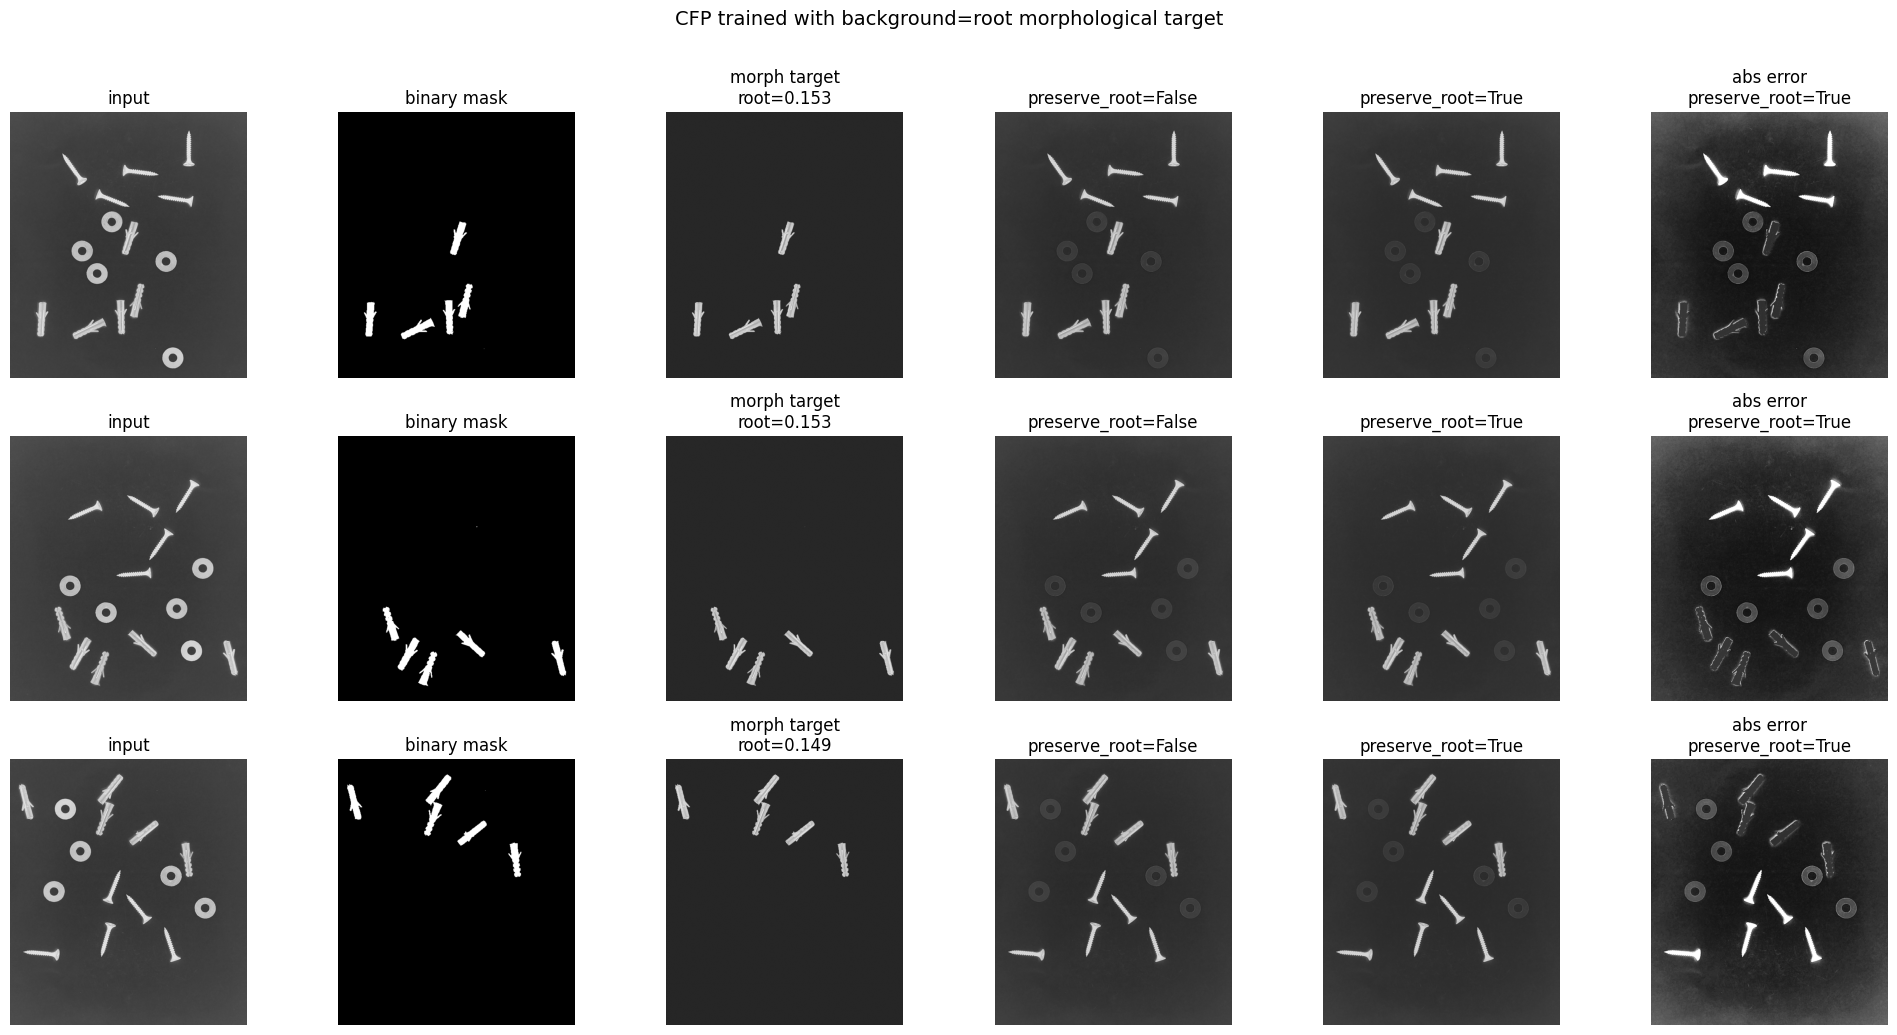

In [33]:
@torch.no_grad()
def plot_results(loader, title):
    cfp_layer.eval()
    batch = next(iter(loader))
    model_input, x, target, _, mask, root = split_precomputed_batch(batch)
    pred = cfp_unit_output(cfp_layer, model_input)

    n = min(PLOT_SAMPLES, x.shape[0])
    fig, axes = plt.subplots(n, 6, figsize=(20, 3.4 * n), squeeze=False)
    fig.suptitle(title, y=1.01, fontsize=14)

    for i in range(n):
        panels = [
            (x[i, 0], "input"),
            (mask[i, 0], "binary mask"),
            (target[i, 0], f"morph target\nroot={float(root[i, 0, 0, 0]):.3f}"),
            (pred[i, 0], "preserve_root=False"),
            (pred[i, 1], "preserve_root=True"),
            ((pred[i, 1] - target[i, 0]).abs(), "abs error\npreserve_root=True"),
        ]
        for ax, (image, panel_title) in zip(axes[i], panels):
            vmax = 1.0 if "abs error" not in panel_title else 0.25
            ax.imshow(image.detach().cpu(), cmap="gray", vmin=0.0, vmax=vmax)
            ax.set_title(panel_title)
            ax.axis("off")

    plt.tight_layout()
    plt.show()


plot_results(plot_target_loader, "CFP trained with background=root morphological target")

## Loss curve

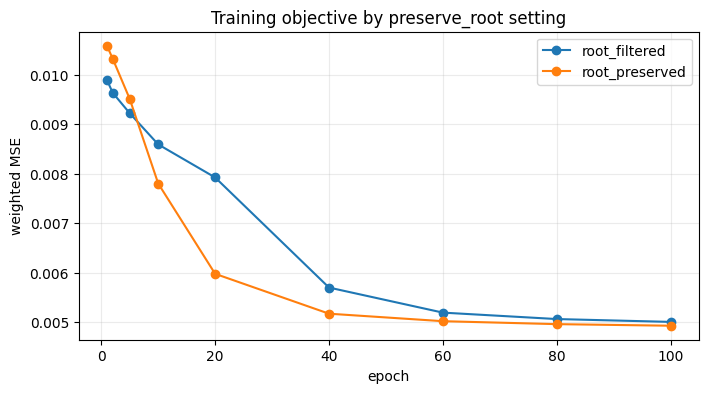

In [34]:
if history:
    epochs = [item[0] for item in history]
    plt.figure(figsize=(8, 4))
    for name in spec_names:
        values = [item[1][name]["weighted_mse"] for item in history]
        plt.plot(epochs, values, marker="o", label=name)
    plt.xlabel("epoch")
    plt.ylabel("weighted MSE")
    plt.title("Training objective by preserve_root setting")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()

## Interpretation

This target is compatible with `preserve_root=True` because the desired background is not zero. It is the max-tree root level. The layer is therefore allowed to suppress non-root residues while keeping the global baseline.

This does not make the CFP layer a direct binary segmenter. It makes it a trainable connected filter that uses a binary mask only to define which gray-level structures should remain above the baseline. If the final task is segmentation, this filtered image should usually feed a subsequent decision layer or network head.